# Dynamic Factor Model — Tone as a Contemporaneous Indicator of Latent Salience

**Objective.** Test whether *tone* behaves as a contemporaneous indicator of a latent
*salience* factor $f_t$, alongside search activity and media coverage.

This notebook implements the full **Design & Check Plan** as runnable code:

| Series | Meaning | Transformation |
|---|---|---|
| `GT` | Google Trends search activity | $\log(1+\text{GT})$ |
| `MediaCloud_raw` | raw article count | $\log(1+\text{MediaCloud})$ |
| `Tone` | GDELT general AI tone | as-is / standardized |

**Model (single-factor state space).** The latent salience $f_t$ follows a random walk
and is measured by up to three indicators:

$$\log(1+GT_t)      = \mu_1 + \lambda_1 f_t + \varepsilon_{1t}$$
$$\log(1+MediaCloud_t) = \mu_2 + \lambda_2 f_t + \varepsilon_{2t}$$
$$Tone_t             = \mu_3 + \lambda_3 f_t + \varepsilon_{3t}$$
$$\varepsilon_{it}\sim N(0,\sigma_i^2)\ \text{(independent)},\qquad
  f_t = f_{t-1} + \eta_t,\quad \eta_t\sim N(0,\sigma_\eta^2)$$

**Identification.** Fix $\lambda_1 = 1$ to set the scale of $f_t$.

**Specifications.**

* **Model A** — GT only ($\lambda_2=\lambda_3=0$)
* **Model B** — GT + MediaCloud ($\lambda_2$ free, $\lambda_3=0$)
* **Model C** — GT + MediaCloud + Tone ($\lambda_2,\lambda_3$ free)

Estimation is by **maximum likelihood** via the Kalman filter (`statsmodels` state space).
The class is written so the same code also supports a restricted variant ($\lambda_3=0$ on the
full 3-series data) needed for a clean fit comparison (see the "Model fit" section).


## 0 · Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.mlemodel import MLEModel
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
RNG = np.random.default_rng(42)
print("Environment ready.")

Environment ready.


## 1 · Data

Weekly series aligned by date. **Levels, not first differences.**

Drop your real weekly file into the working directory as `salience_weekly.csv` with columns
`date, GT, MediaCloud_raw, Tone` (and optionally `MediaCloud_share`). If that file is not
present, the notebook falls back to a **simulated dataset** with a known factor so every check
below runs end-to-end and can be validated against ground truth.

In [2]:
DATA_PATH = "salience_weekly.csv"

def load_real_data(path):
    df = pd.read_csv(path, parse_dates=["date"]).set_index("date").sort_index()
    df = df.rename(columns={"MediaCloud_raw": "MediaCloud"})
    return df

def simulate_data(T=180, seed=42):
    """Simulate a random-walk factor with a deliberately WEAK tone loading."""
    rng = np.random.default_rng(seed)
    f = np.cumsum(rng.normal(0, 1.0, T))            # latent salience (random walk)
    dates = pd.date_range("2021-01-03", periods=T, freq="W")
    # Build indicators on the *observed* scale, then invert the planned transforms
    # so the raw columns look like real GT/article-count/tone inputs.
    logGT = 3.0 + 1.00 * f + rng.normal(0, 0.45, T)          # lambda_1 = 1  (truth)
    logMC = 2.5 + 0.80 * f + rng.normal(0, 0.55, T)          # lambda_2 = 0.8 (truth)
    tone  = 0.0 + 0.15 * f + rng.normal(0, 1.00, T)          # lambda_3 = 0.15 (WEAK)
    df = pd.DataFrame({
        "GT":         np.clip(np.expm1(logGT), 0, None).round(),
        "MediaCloud": np.clip(np.expm1(logMC), 0, None).round(),
        "Tone":       tone,
    }, index=dates)
    return df, f

TRUE_F = None
try:
    data = load_real_data(DATA_PATH)
    print(f"Loaded real data from {DATA_PATH}: {data.shape[0]} weeks.")
except FileNotFoundError:
    data, TRUE_F = simulate_data()
    print("No CSV found — using SIMULATED data (true loadings: lambda_2=0.80, lambda_3=0.15).")

data.head()

No CSV found — using SIMULATED data (true loadings: lambda_2=0.80, lambda_3=0.15).


,GT,MediaCloud,Tone
2021-01-03,48.0000,13.0000,-1.6408
2021-01-10,10.0000,7.0000,-0.9365
2021-01-17,16.0000,20.0000,0.2499
2021-01-24,85.0000,14.0000,-0.0359
2021-01-31,8.0000,4.0000,-0.4027


## 2 · Transformations

* $\log(1+GT)$ and $\log(1+MediaCloud)$ compress the heavy right tail of counts.
* `Tone` is kept on its native scale here; a standardized-tone robustness switch is provided.
* Each series is then **demeaned** so the intercepts $\mu_i$ drop out of the state space
  (a Gaussian model with a demeaned observation is equivalent to estimating $\mu_i$ explicitly).
  The relative *scale* across series is preserved, which is what the $\lambda_1=1$ identification
  needs.

In [3]:
STANDARDIZE_TONE = False   # robustness switch: set True to z-score Tone

work = pd.DataFrame(index=data.index)
work["GT"]         = np.log1p(data["GT"])
work["MediaCloud"] = np.log1p(data["MediaCloud"])
work["Tone"]       = (data["Tone"] - data["Tone"].mean()) / data["Tone"].std() \
                     if STANDARDIZE_TONE else data["Tone"].astype(float)

# Demean so mu_i = 0 in the state space (means stored for reference).
series_means = work.mean()
Z = work - series_means
print("Series means (mu_i):")
print(series_means)
Z.describe().T[["mean", "std", "min", "max"]]

Series means (mu_i):
GT            2.2506
MediaCloud    1.8418
Tone         -0.5883
dtype: float64


,mean,std,min,max
GT,0.0000,2.5669,-2.2506,6.2565
MediaCloud,0.0000,2.0829,-1.8418,4.5366
Tone,-0.0000,1.2499,-3.3051,3.3530


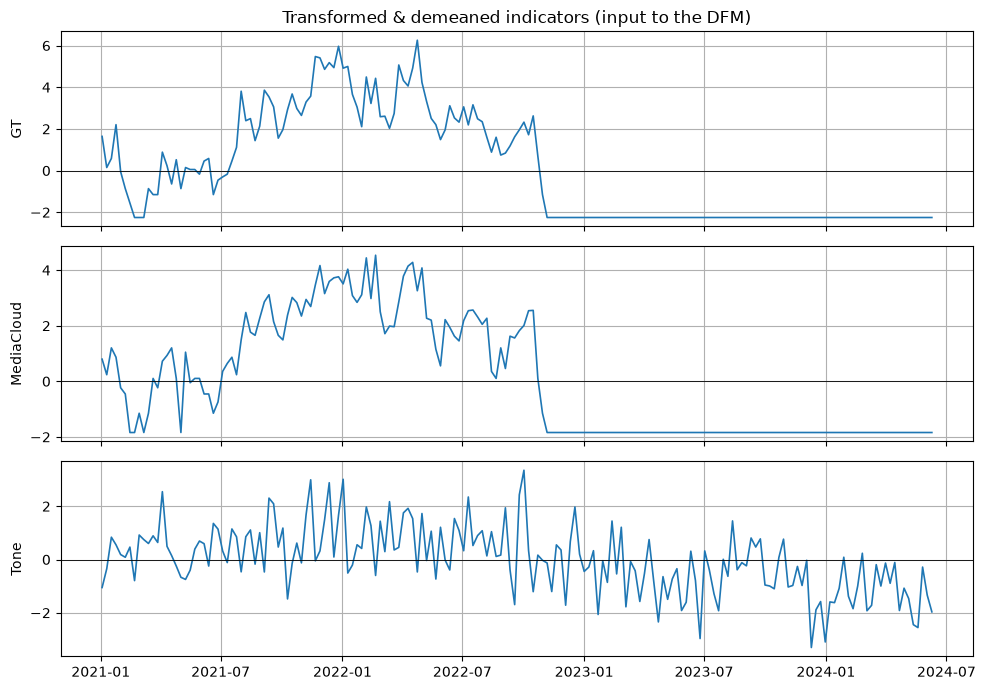

In [4]:
fig, ax = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
for a, col in zip(ax, ["GT", "MediaCloud", "Tone"]):
    a.plot(Z.index, Z[col], lw=1.2)
    a.set_ylabel(col)
    a.axhline(0, color="k", lw=.6)
ax[0].set_title("Transformed & demeaned indicators (input to the DFM)")
plt.tight_layout(); plt.show()

## 3 · Model specification (state-space class)

State-space form with a single latent state $f_t$:

$$
\underbrace{y_t}_{k\times1} = \underbrace{Z}_{k\times1} f_t + \varepsilon_t,\quad
\varepsilon_t \sim N(0, H),\qquad
f_t = f_{t-1} + \eta_t,\quad \eta_t \sim N(0,\sigma_\eta^2)
$$

with $Z=[\,1,\ \lambda_2,\ \lambda_3\,]^\top$ (the leading $1$ fixes $\lambda_1$), and
$H=\mathrm{diag}(\sigma_1^2,\sigma_2^2,\sigma_3^2)$.

`free_loadings` lists which indicator loadings ($\ge$ the second) are estimated; any indicator
included in the data but *not* in `free_loadings` is held at $\lambda=0$. That single argument
generates Models A, B, C **and** the restricted "$\lambda_3=0$ on 3 series" model used for the
fit comparison. The nonstationary random-walk state uses approximate-diffuse initialization.

In [5]:
class SalienceDFM(MLEModel):
    """Single-factor DFM with a random-walk latent factor and lambda_1 = 1.

    Parameters
    ----------
    endog : array (n_obs x k_endog), demeaned. Column 0 is the anchor (lambda_1 = 1).
    free_loadings : list of column indices (>= 1) whose loading is estimated.
                    Columns not listed are held at lambda = 0 (still contribute a
                    variance term, i.e. treated as noise around their mean).
    """
    def __init__(self, endog, free_loadings):
        self.free_loadings = list(free_loadings)
        endog = np.asarray(endog, float)
        if endog.ndim == 1:
            endog = endog[:, None]
        self._k = endog.shape[1]
        super().__init__(endog, k_states=1, k_posdef=1,
                         initialization="approximate_diffuse")
        self["transition", 0, 0] = 1.0
        self["selection", 0, 0]  = 1.0
        self["design", 0, 0]     = 1.0            # lambda_1 fixed

    @property
    def param_names(self):
        return ([f"lambda_{i+1}" for i in self.free_loadings]
                + [f"sigma2_eps_{i+1}" for i in range(self._k)]
                + ["sigma2_eta"])

    @property
    def start_params(self):
        return np.r_[np.ones(len(self.free_loadings)),
                     np.var(self.endog, axis=0).ravel() * 0.5,
                     1.0]

    def transform_params(self, u):
        n = len(self.free_loadings)
        c = u.copy(); c[n:] = u[n:] ** 2           # variances > 0
        return c

    def untransform_params(self, c):
        n = len(self.free_loadings)
        u = c.copy(); u[n:] = np.sqrt(c[n:])
        return u

    def update(self, params, **kwargs):
        params = super().update(params, **kwargs)
        n = len(self.free_loadings)
        loadings = params[:n]
        eps_var  = params[n:n + self._k]
        eta_var  = params[n + self._k]
        for pos, idx in enumerate(self.free_loadings):
            self["design", idx, 0] = loadings[pos]
        self["obs_cov"] = np.diag(eps_var)
        self["state_cov", 0, 0] = eta_var


def fit_dfm(endog, free_loadings, label):
    mod = SalienceDFM(endog.values, free_loadings)
    res = mod.fit(disp=False, maxiter=500)
    res = mod.fit(res.params, disp=False, maxiter=500, method="nm")  # polish
    res.label = label
    return res

print("SalienceDFM defined.")

SalienceDFM defined.


## 4 · Estimate Models A, B, C

In [6]:
SPECS = {
    "A: GT":               (Z[["GT"]],                       []),
    "B: GT+MC":            (Z[["GT", "MediaCloud"]],         [1]),
    "C: GT+MC+Tone":       (Z[["GT", "MediaCloud", "Tone"]], [1, 2]),
}

results = {}
for label, (endog, free) in SPECS.items():
    results[label] = fit_dfm(endog, free, label)
    r = results[label]
    conv = r.mle_retvals["converged"]
    print(f"{label:16s} | converged={conv} | logL={r.llf:9.2f} | "
          f"AIC={r.aic:8.1f} | BIC={r.bic:8.1f}")

A: GT            | converged=True | logL=  -208.68 | AIC=   421.4 | BIC=   427.8
B: GT+MC         | converged=True | logL=  -309.70 | AIC=   627.4 | BIC=   640.2


C: GT+MC+Tone    | converged=True | logL=  -574.29 | AIC=  1160.6 | BIC=  1179.7


In [7]:
def loadings_table(res):
    rows = []
    for name, est, se in zip(res.model.param_names, res.params, res.bse):
        if name.startswith("lambda"):
            lo, hi = est - 1.96 * se, est + 1.96 * se
            rows.append({"param": name, "estimate": est, "se": se,
                         "ci_low": lo, "ci_high": hi,
                         "excludes_0": (lo > 0) or (hi < 0)})
    return pd.DataFrame(rows).set_index("param")

print("Model C — estimated free loadings with 95% CIs:")
loadings_table(results["C: GT+MC+Tone"])

Model C — estimated free loadings with 95% CIs:


,estimate,se,ci_low,ci_high,excludes_0
param,,,,,
lambda_2,0.8088,0.0121,0.7850,0.8326,True
lambda_3,0.2651,0.0298,0.2068,0.3235,True


## Check 1 · Factor loadings

**Question.** Is $\lambda_2$ clearly $\ne 0$? Is $\lambda_3$ clearly $\ne 0$? Are the intervals
narrow enough?

**Decision rule.** If $\lambda_3$ is small or its interval includes $0$ → *tone is not a useful
indicator*.

In [8]:
tbl = loadings_table(results["C: GT+MC+Tone"])
display(tbl)

for p in tbl.index:
    est = tbl.loc[p, "estimate"]; lo = tbl.loc[p, "ci_low"]; hi = tbl.loc[p, "ci_high"]
    verdict = "clearly != 0" if tbl.loc[p, "excludes_0"] else "NOT distinguishable from 0"
    print(f"{p}: {est:.3f}  95% CI [{lo:.3f}, {hi:.3f}]  ->  {verdict}")

l3 = tbl.loc["lambda_3"]
ci_width = l3["ci_high"] - l3["ci_low"]
print(f"\nlambda_3 CI width = {ci_width:.3f}")
print("DECISION (Check 1):",
      "CI includes 0 -> tone is NOT a useful indicator"
      if not l3["excludes_0"]
      else "CI excludes 0 -> tone loading is distinguishable from zero "
           "(judge its *strength* with the standardized loading in Check 2)")

,estimate,se,ci_low,ci_high,excludes_0
param,,,,,
lambda_2,0.8088,0.0121,0.7850,0.8326,True
lambda_3,0.2651,0.0298,0.2068,0.3235,True


lambda_2: 0.809  95% CI [0.785, 0.833]  ->  clearly != 0
lambda_3: 0.265  95% CI [0.207, 0.323]  ->  clearly != 0

lambda_3 CI width = 0.117
DECISION (Check 1): CI excludes 0 -> tone loading is distinguishable from zero (judge its *strength* with the standardized loading in Check 2)


## Check 2 · Standardized loadings

Scale-free strength of each indicator:

$$\tilde\lambda_i = \frac{\lambda_i\,\sigma_f}{\sqrt{\lambda_i^2\,\sigma_f^2 + \sigma_i^2}}$$

Because $f_t$ is a random walk (no finite unconditional variance), we use the sample standard
deviation of the **smoothed** factor as $\sigma_f$ — a standard practical choice.
**A standardized loading below ~0.3 is weak.**

In [9]:
def standardized_loadings(res):
    sm = res.smoothed_state[0]           # E[f_t | all data]
    sigma_f = np.std(sm, ddof=1)
    names = res.model.param_names
    # loading for every endog column (1.0 for the fixed anchor / 0 for excluded)
    load = {}
    load[0] = 1.0
    for i in res.model.free_loadings:
        load[i] = res.params[names.index(f"lambda_{i+1}")]
    for i in range(res.model._k):
        load.setdefault(i, 0.0)
    eps = {i: res.params[names.index(f"sigma2_eps_{i+1}")] for i in range(res.model._k)}
    rows = []
    for i in range(res.model._k):
        li = load[i]
        std = li * sigma_f / np.sqrt(li**2 * sigma_f**2 + eps[i])
        rows.append({"indicator": res.model.endog_names[i] if hasattr(res.model,'endog_names') else i,
                     "lambda": li, "std_loading": std,
                     "weak(<0.3)": abs(std) < 0.3})
    return sigma_f, pd.DataFrame(rows)

sigma_f, std_tbl = standardized_loadings(results["C: GT+MC+Tone"])
std_tbl.index = ["GT", "MediaCloud", "Tone"]
print(f"sigma_f (sd of smoothed factor) = {sigma_f:.3f}")
std_tbl[["lambda", "std_loading", "weak(<0.3)"]]

sigma_f (sd of smoothed factor) = 2.528


,lambda,std_loading,weak(<0.3)
GT,1.0000,0.9889,False
MediaCloud,0.8088,0.9858,False
Tone,0.2651,0.5379,False


## Check 3 · Model fit comparison

**Important caveat.** AIC/BIC are only comparable across models fit to the **same** observed
data. Model B (2 series) and Model C (3 series) use *different* endog dimensions, so their
log-likelihoods are not directly comparable. To isolate tone's contribution we compare, on the
**same 3-series data**:

* **Model C** — $\lambda_3$ free
* **Model C₀** — $\lambda_3 = 0$ (tone present but forced to load nothing)

That pair is nested, so AIC/BIC, and a **likelihood-ratio test** on 1 df, are all valid.
We also report **out-of-sample** one-step prediction RMSE on the shared indicators.

**Decision rule.** If Model C does not improve fit substantially → exclude tone.

In [10]:
endog3 = Z[["GT", "MediaCloud", "Tone"]]
mC  = results["C: GT+MC+Tone"]
mC0 = fit_dfm(endog3, [1], "C0: lambda_3=0")   # tone included, loading fixed at 0

lr_stat = 2 * (mC.llf - mC0.llf)
lr_p    = stats.chi2.sf(lr_stat, df=1)

cmp = pd.DataFrame({
    "logL": [mC0.llf, mC.llf],
    "k_params": [len(mC0.params), len(mC.params)],
    "AIC": [mC0.aic, mC.aic],
    "BIC": [mC0.bic, mC.bic],
}, index=["C0 (lambda_3=0)", "C (lambda_3 free)"])
display(cmp)
print(f"Delta AIC (C - C0) = {mC.aic - mC0.aic:+.2f}   "
      f"Delta BIC (C - C0) = {mC.bic - mC0.bic:+.2f}")
print(f"Likelihood-ratio test for lambda_3=0:  LR={lr_stat:.2f}, "
      f"df=1, p={lr_p:.4g}")
print("DECISION (Check 3):",
      "tone improves fit -> keep" if (mC.bic < mC0.bic and lr_p < 0.05)
      else "tone does NOT substantially improve fit -> exclude")

,logL,k_params,AIC,BIC
C0 (lambda_3=0),-604.7608,5,"1,219.5217","1,235.4865"
C (lambda_3 free),-574.2911,6,"1,160.5822","1,179.7400"


Delta AIC (C - C0) = -58.94   Delta BIC (C - C0) = -55.75
Likelihood-ratio test for lambda_3=0:  LR=60.94, df=1, p=5.886e-15
DECISION (Check 3): tone improves fit -> keep


In [11]:
# Out-of-sample: hold out the last 20% of weeks, refit, score 1-step predictions
# on the shared indicators (GT, MediaCloud) so B and C are scored on the same targets.
def oos_rmse(endog, free, h_frac=0.2, score_cols=("GT", "MediaCloud")):
    n = len(endog); n_test = max(4, int(round(n * h_frac)))
    train, test = endog.iloc[:-n_test], endog.iloc[-n_test:]
    res = fit_dfm(train, free, "oos")
    # extend the fitted model over the full sample and read filtered 1-step forecasts
    full = SalienceDFM(endog.values, free).smooth(res.params)
    pred = full.get_prediction()
    mean = pd.DataFrame(pred.predicted_mean, index=endog.index, columns=endog.columns)
    err = (endog[list(score_cols)] - mean[list(score_cols)]).iloc[-n_test:]
    return np.sqrt((err**2).mean())

rmse_B = oos_rmse(Z[["GT", "MediaCloud"]],         [1])
rmse_C = oos_rmse(Z[["GT", "MediaCloud", "Tone"]], [1, 2])
oos = pd.DataFrame({"Model B (GT+MC)": rmse_B, "Model C (GT+MC+Tone)": rmse_C})
print("Out-of-sample 1-step RMSE on shared indicators (lower = better):")
oos

Out-of-sample 1-step RMSE on shared indicators (lower = better):


,Model B (GT+MC),Model C (GT+MC+Tone)
GT,0.0142,0.0312
MediaCloud,0.0155,0.0137


## Check 4 · Latent factor properties

Plot the estimated $f_t$ against the observed levels. Does it capture the common low-frequency
trend? A **small $\sigma_\eta^2$** implies a smooth, slowly-moving salience.

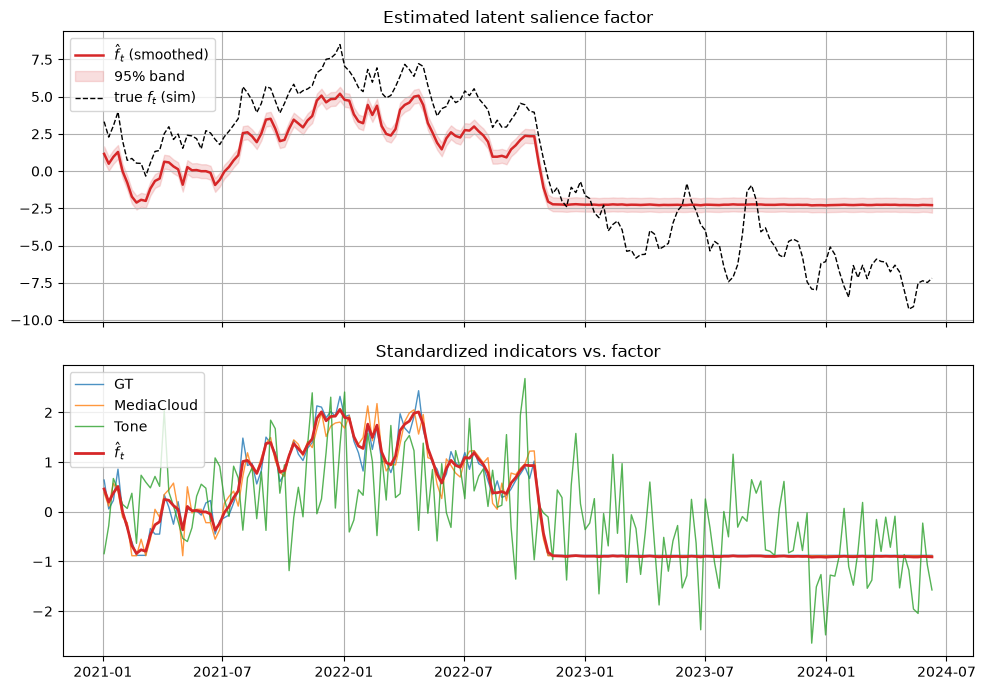

sigma2_eta = 0.3124  -> smooth salience (small state innovation)
corr(f_hat, indicator): {'GT': np.float64(0.993), 'MediaCloud': np.float64(0.99), 'Tone': np.float64(0.541)}


In [12]:
resC = results["C: GT+MC+Tone"]
f_hat = resC.smoothed_state[0]
f_se  = np.sqrt(resC.smoothed_state_cov[0, 0])

fig, ax = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
ax[0].plot(Z.index, f_hat, color="C3", lw=1.8, label=r"$\hat f_t$ (smoothed)")
ax[0].fill_between(Z.index, f_hat - 1.96*f_se, f_hat + 1.96*f_se,
                   color="C3", alpha=.15, label="95% band")
if TRUE_F is not None:
    ax[0].plot(Z.index, TRUE_F - TRUE_F.mean(), "k--", lw=1, label="true $f_t$ (sim)")
ax[0].set_title("Estimated latent salience factor"); ax[0].legend(loc="upper left")

for col, c in zip(["GT", "MediaCloud", "Tone"], ["C0", "C1", "C2"]):
    s = (Z[col] - Z[col].mean()) / Z[col].std()
    ax[1].plot(Z.index, s, c, lw=1, alpha=.8, label=col)
ax[1].plot(Z.index, (f_hat - f_hat.mean())/f_hat.std(), "C3", lw=2, label=r"$\hat f_t$")
ax[1].set_title("Standardized indicators vs. factor"); ax[1].legend(loc="upper left")
plt.tight_layout(); plt.show()

names = resC.model.param_names
sig_eta = resC.params[names.index("sigma2_eta")]
print(f"sigma2_eta = {sig_eta:.4f}  ->",
      "smooth salience (small state innovation)" if sig_eta < 1
      else "volatile salience (large state innovation)")

corrs = {c: np.corrcoef(f_hat, Z[c])[0, 1] for c in ["GT", "MediaCloud", "Tone"]}
print("corr(f_hat, indicator):", {k: round(v, 3) for k, v in corrs.items()})

## Check 5 · Residual diagnostics

Standardized one-step prediction residuals should be approximately white noise. We run a
**Ljung–Box** test per indicator for remaining autocorrelation (p < 0.05 flags structure the
model has not captured).

,LB_stat(8),p_value,white_noise(p>0.05)
GT,13.4241,0.0981,True
MediaCloud,14.7090,0.0651,True
Tone,14.5191,0.0692,True


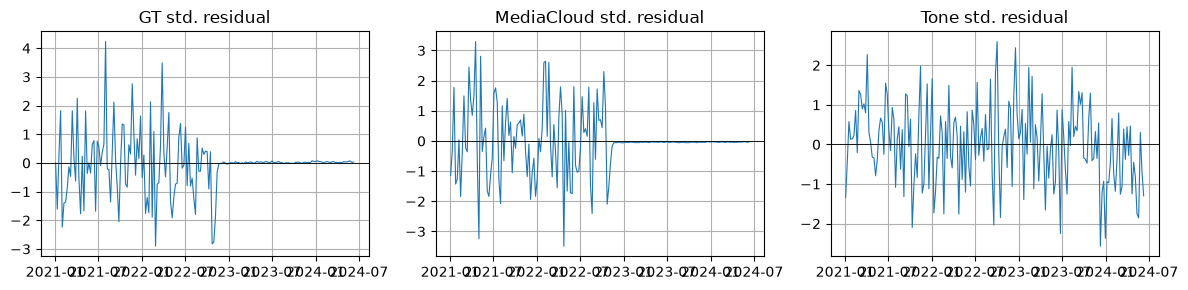

In [13]:
resid = pd.DataFrame(resC.standardized_forecasts_error.T,
                     index=Z.index, columns=["GT", "MediaCloud", "Tone"]).dropna()

lb = {c: acorr_ljungbox(resid[c], lags=[8], return_df=True)
      for c in resid.columns}
lb_tbl = pd.DataFrame({c: {"LB_stat(8)": lb[c]["lb_stat"].iloc[0],
                           "p_value":   lb[c]["lb_pvalue"].iloc[0]}
                       for c in resid.columns}).T
lb_tbl["white_noise(p>0.05)"] = lb_tbl["p_value"] > 0.05
display(lb_tbl)

fig, ax = plt.subplots(1, 3, figsize=(12, 3))
for a, c in zip(ax, resid.columns):
    a.plot(resid.index, resid[c], lw=.8); a.axhline(0, color="k", lw=.6)
    a.set_title(f"{c} std. residual")
plt.tight_layout(); plt.show()

## Check 6 · Convergence & identification (MLE)

For maximum likelihood we check the optimizer converged and that standard errors are finite and
sensible (a diffuse/near-singular Hessian shows up as `NaN`/huge SEs and signals a weakly
identified parameter).

In [14]:
diag = []
for label, r in results.items():
    ses = r.bse
    diag.append({
        "model": label,
        "converged": r.mle_retvals["converged"],
        "n_iter": r.mle_retvals.get("iterations", np.nan),
        "max_|param|": np.max(np.abs(r.params)),
        "any_nan_se": bool(np.any(~np.isfinite(ses))),
        "max_se": np.max(ses[np.isfinite(ses)]) if np.any(np.isfinite(ses)) else np.nan,
    })
pd.DataFrame(diag).set_index("model")

,converged,n_iter,max_|param|,any_nan_se,max_se
model,,,,,
A: GT,True,18,0.3817,False,0.0542
B: GT+MC,True,61,0.8084,False,0.0353
C: GT+MC+Tone,True,90,1.1030,False,0.1247


## 5 · Summary & decision

The table maps the observed evidence to the plan's expected outcomes:

| Result | Interpretation |
|---|---|
| Tone loads strongly, fit improves | Tone **can** be a measurement indicator |
| Tone loads weakly, fit does not improve | Tone should **not** be in the measurement equation; treat as driver/moderator |
| MediaCloud loads weakly | MediaCloud may be better as a **lagged driver**, not an indicator |

The cell below assembles the automatic verdict from the checks above.

In [15]:
tbl = loadings_table(results["C: GT+MC+Tone"])
_, std_tbl = standardized_loadings(results["C: GT+MC+Tone"]); std_tbl.index = ["GT","MediaCloud","Tone"]
l3, l2 = tbl.loc["lambda_3"], tbl.loc["lambda_2"]
tone_std = abs(std_tbl.loc["Tone", "std_loading"])
mc_std   = abs(std_tbl.loc["MediaCloud", "std_loading"])
fit_improves = (mC.bic < mC0.bic) and (lr_p < 0.05)

print("="*64)
print("AUTOMATED VERDICT")
print("="*64)
print(f"lambda_2 (MediaCloud) = {l2['estimate']:.3f}  CI[{l2['ci_low']:.3f},{l2['ci_high']:.3f}]  "
      f"std={std_tbl.loc['MediaCloud','std_loading']:.3f}")
print(f"lambda_3 (Tone)       = {l3['estimate']:.3f}  CI[{l3['ci_low']:.3f},{l3['ci_high']:.3f}]  "
      f"std={std_tbl.loc['Tone','std_loading']:.3f}")
print(f"Tone improves fit (BIC down & LR p<0.05): {fit_improves}  (LR p={lr_p:.3g})")
print("-"*64)
if tone_std >= 0.3 and l3["excludes_0"] and fit_improves:
    print("=> TONE loads strongly and improves fit: keep tone as a MEASUREMENT INDICATOR.")
else:
    print("=> TONE loads weakly / no fit gain: do NOT put tone in the measurement")
    print("   equation; treat it as a DRIVER / MODERATOR of salience instead.")
if mc_std < 0.3:
    print("=> MEDIACLOUD loads weakly: consider it a LAGGED DRIVER, not an indicator.")
else:
    print("=> MEDIACLOUD loads adequately as a contemporaneous indicator.")

AUTOMATED VERDICT
lambda_2 (MediaCloud) = 0.809  CI[0.785,0.833]  std=0.986
lambda_3 (Tone)       = 0.265  CI[0.207,0.323]  std=0.538
Tone improves fit (BIC down & LR p<0.05): True  (LR p=5.89e-15)
----------------------------------------------------------------
=> TONE loads strongly and improves fit: keep tone as a MEASUREMENT INDICATOR.
=> MEDIACLOUD loads adequately as a contemporaneous indicator.


---
### Notes & extensions

* **Bayesian variant.** The plan's DIC/WAIC and R-hat < 1.05 checks apply if you re-estimate the
  same state space in PyMC / Stan with priors on $\lambda_i,\sigma_i^2,\sigma_\eta^2$. The MLE
  results here are the drop-in frequentist analogue (AIC/BIC and Wald CIs).
* **Real data.** Provide `salience_weekly.csv` (`date, GT, MediaCloud_raw, Tone`,
  optionally `MediaCloud_share`) to run on the actual series; everything above is data-agnostic.
* **Robustness.** Flip `STANDARDIZE_TONE = True` (Section 2) or add `MediaCloud_share` as a
  fourth indicator by extending the `SPECS` dict.

**Author:** Andrea Lamacchia
